<a href="https://colab.research.google.com/github/AIntelligent/Conflict-Framework/blob/main/experiment1_conflict_framework_structured.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Conflict Framework Experimential Tests Notebook
\\(\texttt{Kartal, Hakan Emre}\\) ♦
[hek@nula.com.tr](hek@nula.com.tr) ♦ [hakanekartal@yahoo.com](hakanekartal@yahoo.com) ♦
[ORCID: 0000-0002-3952-7235](https://orcid.org/0000-0002-3952-7235)

---

# Experiment 1 — Axiom-Level Behavioral Verification

This notebook visualizes the geometric behavior of the three conflict operators proposed in the Conflict Framework paper and numerically checks:

1. **Zero-conflict consistency**: \( g(x,x)=0 \)
2. **Antisymmetry**: \( g(x,y) = -g(y,x) \)
3. **Grid-based local variation**: no abrupt numerical jumps on the sampled positive domain

The notebook is organized into small, purposeful cells so each stage of the experiment is transparent and reproducible.

```text
MIT License

Copyright (c) 2025 Kartal, Hakan Emre

Permission is hereby granted, free of charge, to any person obtaining a copy
of this software and associated documentation files (the "Software"), to deal
in the Software without restriction, including without limitation the rights
to use, copy, modify, merge, publish, distribute, sublicense, and/or sell
copies of the Software, and to permit persons to whom the Software is
furnished to do so, subject to the following conditions:

THE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND, EXPRESS OR
IMPLIED, INCLUDING BUT NOT LIMITED TO THE WARRANTIES OF MERCHANTABILITY,
FITNESS FOR A PARTICULAR PURPOSE AND NONINFRINGEMENT. IN NO EVENT SHALL THE
AUTHORS OR COPYRIGHT HOLDERS BE LIABLE FOR ANY CLAIM, DAMAGES OR OTHER
LIABILITY, WHETHER IN AN ACTION OF CONTRACT, TORT OR OTHERWISE, ARISING FROM,
OUT OF OR IN CONNECTION WITH THE SOFTWARE OR THE USE OR OTHER DEALINGS IN THE
SOFTWARE.
```


## 1. Imports and plotting configuration

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
import csv

plt.rcParams.update({
    "font.size": 10,
    "axes.labelsize": 10,
    "axes.titlesize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "figure.dpi": 300
})

## 2. Conflict operators

In [ ]:
def g1(x, y):
    """Canonical scale-invariant conflict operator."""
    return (x - y) / (x + y)

def g2(x, y):
    """Log-ratio conflict operator."""
    return np.log(x / y)

def g3(x, y):
    """Raw difference conflict operator."""
    return x - y

## 3. Experimental domain and evaluation grid

In [ ]:
# Theoretical domain: (x, y) in [a, b]^2 with 0 < a < b
# Visualization domain used in this experiment:
a, b = 0.1, 10.0
n = 200

x = np.linspace(a, b, n)
y = np.linspace(a, b, n)
X, Y = np.meshgrid(x, y)

print(f"Domain: [{a}, {b}] × [{a}, {b}]")
print(f"Grid size: {n} × {n}")

Domain: [0.1, 10.0] × [0.1, 10.0]
Grid size: 200 × 200


## 4. Evaluate the operators on the shared grid

In [ ]:
G1 = g1(X, Y)
G2 = g2(X, Y)
G3 = g3(X, Y)

## 5. Numerical checks for the axiomatic properties

In [ ]:
# 5.1 Zero-conflict consistency: g(x, x) = 0
E1_diag = np.max(np.abs(g1(x, x)))
E2_diag = np.max(np.abs(g2(x, x)))
E3_diag = np.max(np.abs(g3(x, x)))

print("Zero-conflict consistency")
print(f"g1: max|g(x,x)| = {E1_diag:.2e}")
print(f"g2: max|g(x,x)| = {E2_diag:.2e}")
print(f"g3: max|g(x,x)| = {E3_diag:.2e}")

Zero-conflict consistency
g1: max|g(x,x)| = 0.00e+00
g2: max|g(x,x)| = 0.00e+00
g3: max|g(x,x)| = 0.00e+00


In [ ]:
# 5.2 Antisymmetry residual: g(x, y) + g(y, x) = 0
E1_anti = np.max(np.abs(G1 + G1.T))
E2_anti = np.max(np.abs(G2 + G2.T))
E3_anti = np.max(np.abs(G3 + G3.T))

print("Antisymmetry residual")
print(f"g1: max|g(x,y)+g(y,x)| = {E1_anti:.2e}")
print(f"g2: max|g(x,y)+g(y,x)| = {E2_anti:.2e}")
print(f"g3: max|g(x,y)+g(y,x)| = {E3_anti:.2e}")

Antisymmetry residual
g1: max|g(x,y)+g(y,x)| = 0.00e+00
g2: max|g(x,y)+g(y,x)| = 8.88e-16
g3: max|g(x,y)+g(y,x)| = 0.00e+00


In [ ]:
# 5.3 Grid-based local variation indicator
# This is a numerical smoothness descriptor, not a formal continuity proof.
dx1 = np.max(np.abs(np.diff(G1, axis=1)))
dy1 = np.max(np.abs(np.diff(G1, axis=0)))

dx2 = np.max(np.abs(np.diff(G2, axis=1)))
dy2 = np.max(np.abs(np.diff(G2, axis=0)))

dx3 = np.max(np.abs(np.diff(G3, axis=1)))
dy3 = np.max(np.abs(np.diff(G3, axis=0)))

print("Grid-based local variation")
print(f"g1: max Δx = {dx1:.4f}, max Δy = {dy1:.4f}")
print(f"g2: max Δx = {dx2:.4f}, max Δy = {dy2:.4f}")
print(f"g3: max Δx = {dx3:.4f}, max Δy = {dy3:.4f}")

Grid-based local variation
g1: max Δx = 0.1992, max Δy = 0.1992
g2: max Δx = 0.4038, max Δy = 0.4038
g3: max Δx = 0.0497, max Δy = 0.0497


## 6. Build a compact summary table

In [ ]:
results = [
    {
        "operator": "g1",
        "max_diag_zero": E1_diag,
        "max_antisymmetry_residual": E1_anti,
        "max_grid_dx": dx1,
        "max_grid_dy": dy1,
        "behavior": "bounded, normalized, scale-invariant",
    },
    {
        "operator": "g2",
        "max_diag_zero": E2_diag,
        "max_antisymmetry_residual": E2_anti,
        "max_grid_dx": dx2,
        "max_grid_dy": dy2,
        "behavior": "ratio-sensitive, unbounded, scale-invariant",
    },
    {
        "operator": "g3",
        "max_diag_zero": E3_diag,
        "max_antisymmetry_residual": E3_anti,
        "max_grid_dx": dx3,
        "max_grid_dy": dy3,
        "behavior": "linear, raw difference, scale-dependent",
    },
]

for row in results:
    print(row)

{'operator': 'g1', 'max_diag_zero': np.float64(0.0), 'max_antisymmetry_residual': np.float64(0.0), 'max_grid_dx': np.float64(0.19919517102615697), 'max_grid_dy': np.float64(0.19919517102615697), 'behavior': 'bounded, normalized, scale-invariant'}
{'operator': 'g2', 'max_diag_zero': np.float64(0.0), 'max_antisymmetry_residual': np.float64(8.881784197001252e-16), 'max_grid_dx': np.float64(0.40378866178091277), 'max_grid_dy': np.float64(0.40378866178091277), 'behavior': 'ratio-sensitive, unbounded, scale-invariant'}
{'operator': 'g3', 'max_diag_zero': np.float64(0.0), 'max_antisymmetry_residual': np.float64(0.0), 'max_grid_dx': np.float64(0.04974874371859528), 'max_grid_dy': np.float64(0.04974874371859528), 'behavior': 'linear, raw difference, scale-dependent'}


In [ ]:
# Optional: save the summary as CSV for direct use in the paper
csv_filename = "experiment1_summary_metrics.csv"

with open(csv_filename, "w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(
        f,
        fieldnames=[
            "operator",
            "max_diag_zero",
            "max_antisymmetry_residual",
            "max_grid_dx",
            "max_grid_dy",
            "behavior",
        ],
    )
    writer.writeheader()
    writer.writerows(results)

print(f"Saved: {csv_filename}")

Saved: experiment1_summary_metrics.csv


## 7. Publication-oriented contour figure

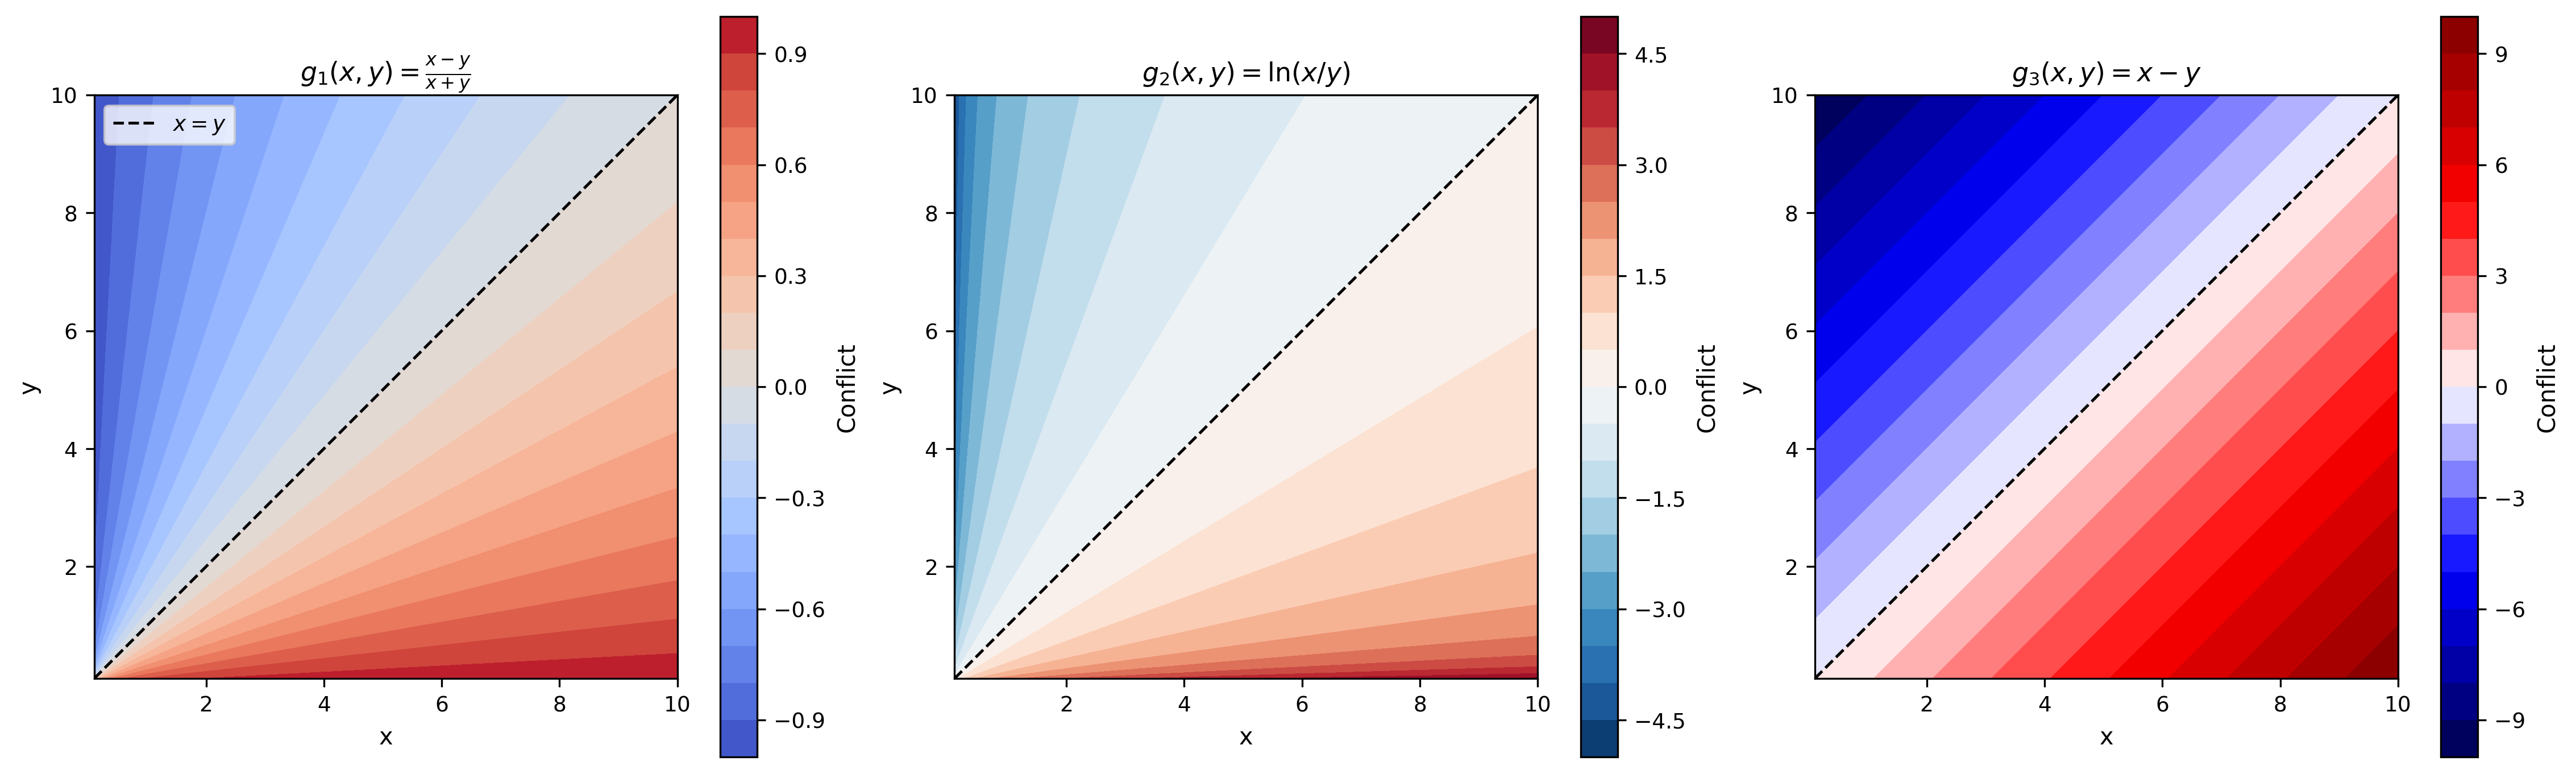

Saved: experiment1_contour_panels.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.8), constrained_layout=True)

diag_x = [a, b]
diag_y = [a, b]

# Panel 1: g1
levels_g1 = np.linspace(-1, 1, 21)
cont1 = axes[0].contourf(
    X, Y, G1, levels=levels_g1, cmap="coolwarm", vmin=-1, vmax=1
)
axes[0].plot(diag_x, diag_y, "k--", linewidth=1.2, label=r"$x=y$")
axes[0].set_title(r"$g_1(x,y)=\frac{x-y}{x+y}$")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].set_aspect("equal")
axes[0].legend(loc="upper left", frameon=True)
cbar1 = fig.colorbar(cont1, ax=axes[0], shrink=0.92)
cbar1.set_label("Conflict")

# Panel 2: g2
g2_lim = 5.0
levels_g2 = np.linspace(-g2_lim, g2_lim, 21)
cont2 = axes[1].contourf(
    X, Y, G2, levels=levels_g2, cmap="RdBu_r", vmin=-g2_lim, vmax=g2_lim
)
axes[1].plot(diag_x, diag_y, "k--", linewidth=1.2)
axes[1].set_title(r"$g_2(x,y)=\ln(x/y)$")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
axes[1].set_aspect("equal")
cbar2 = fig.colorbar(cont2, ax=axes[1], shrink=0.92)
cbar2.set_label("Conflict")

# Panel 3: g3
g3_lim = 10.0
levels_g3 = np.linspace(-g3_lim, g3_lim, 21)
cont3 = axes[2].contourf(
    X, Y, G3, levels=levels_g3, cmap="seismic", vmin=-g3_lim, vmax=g3_lim
)
axes[2].plot(diag_x, diag_y, "k--", linewidth=1.2)
axes[2].set_title(r"$g_3(x,y)=x-y$")
axes[2].set_xlabel("x")
axes[2].set_ylabel("y")
axes[2].set_aspect("equal")
cbar3 = fig.colorbar(cont3, ax=axes[2], shrink=0.92)
cbar3.set_label("Conflict")

publication_fig = "experiment1_contour_panels.png"
plt.savefig(publication_fig, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved: {publication_fig}")

## 8. Optional exploratory 3D surfaces

In [ ]:
make_3d_figure = True

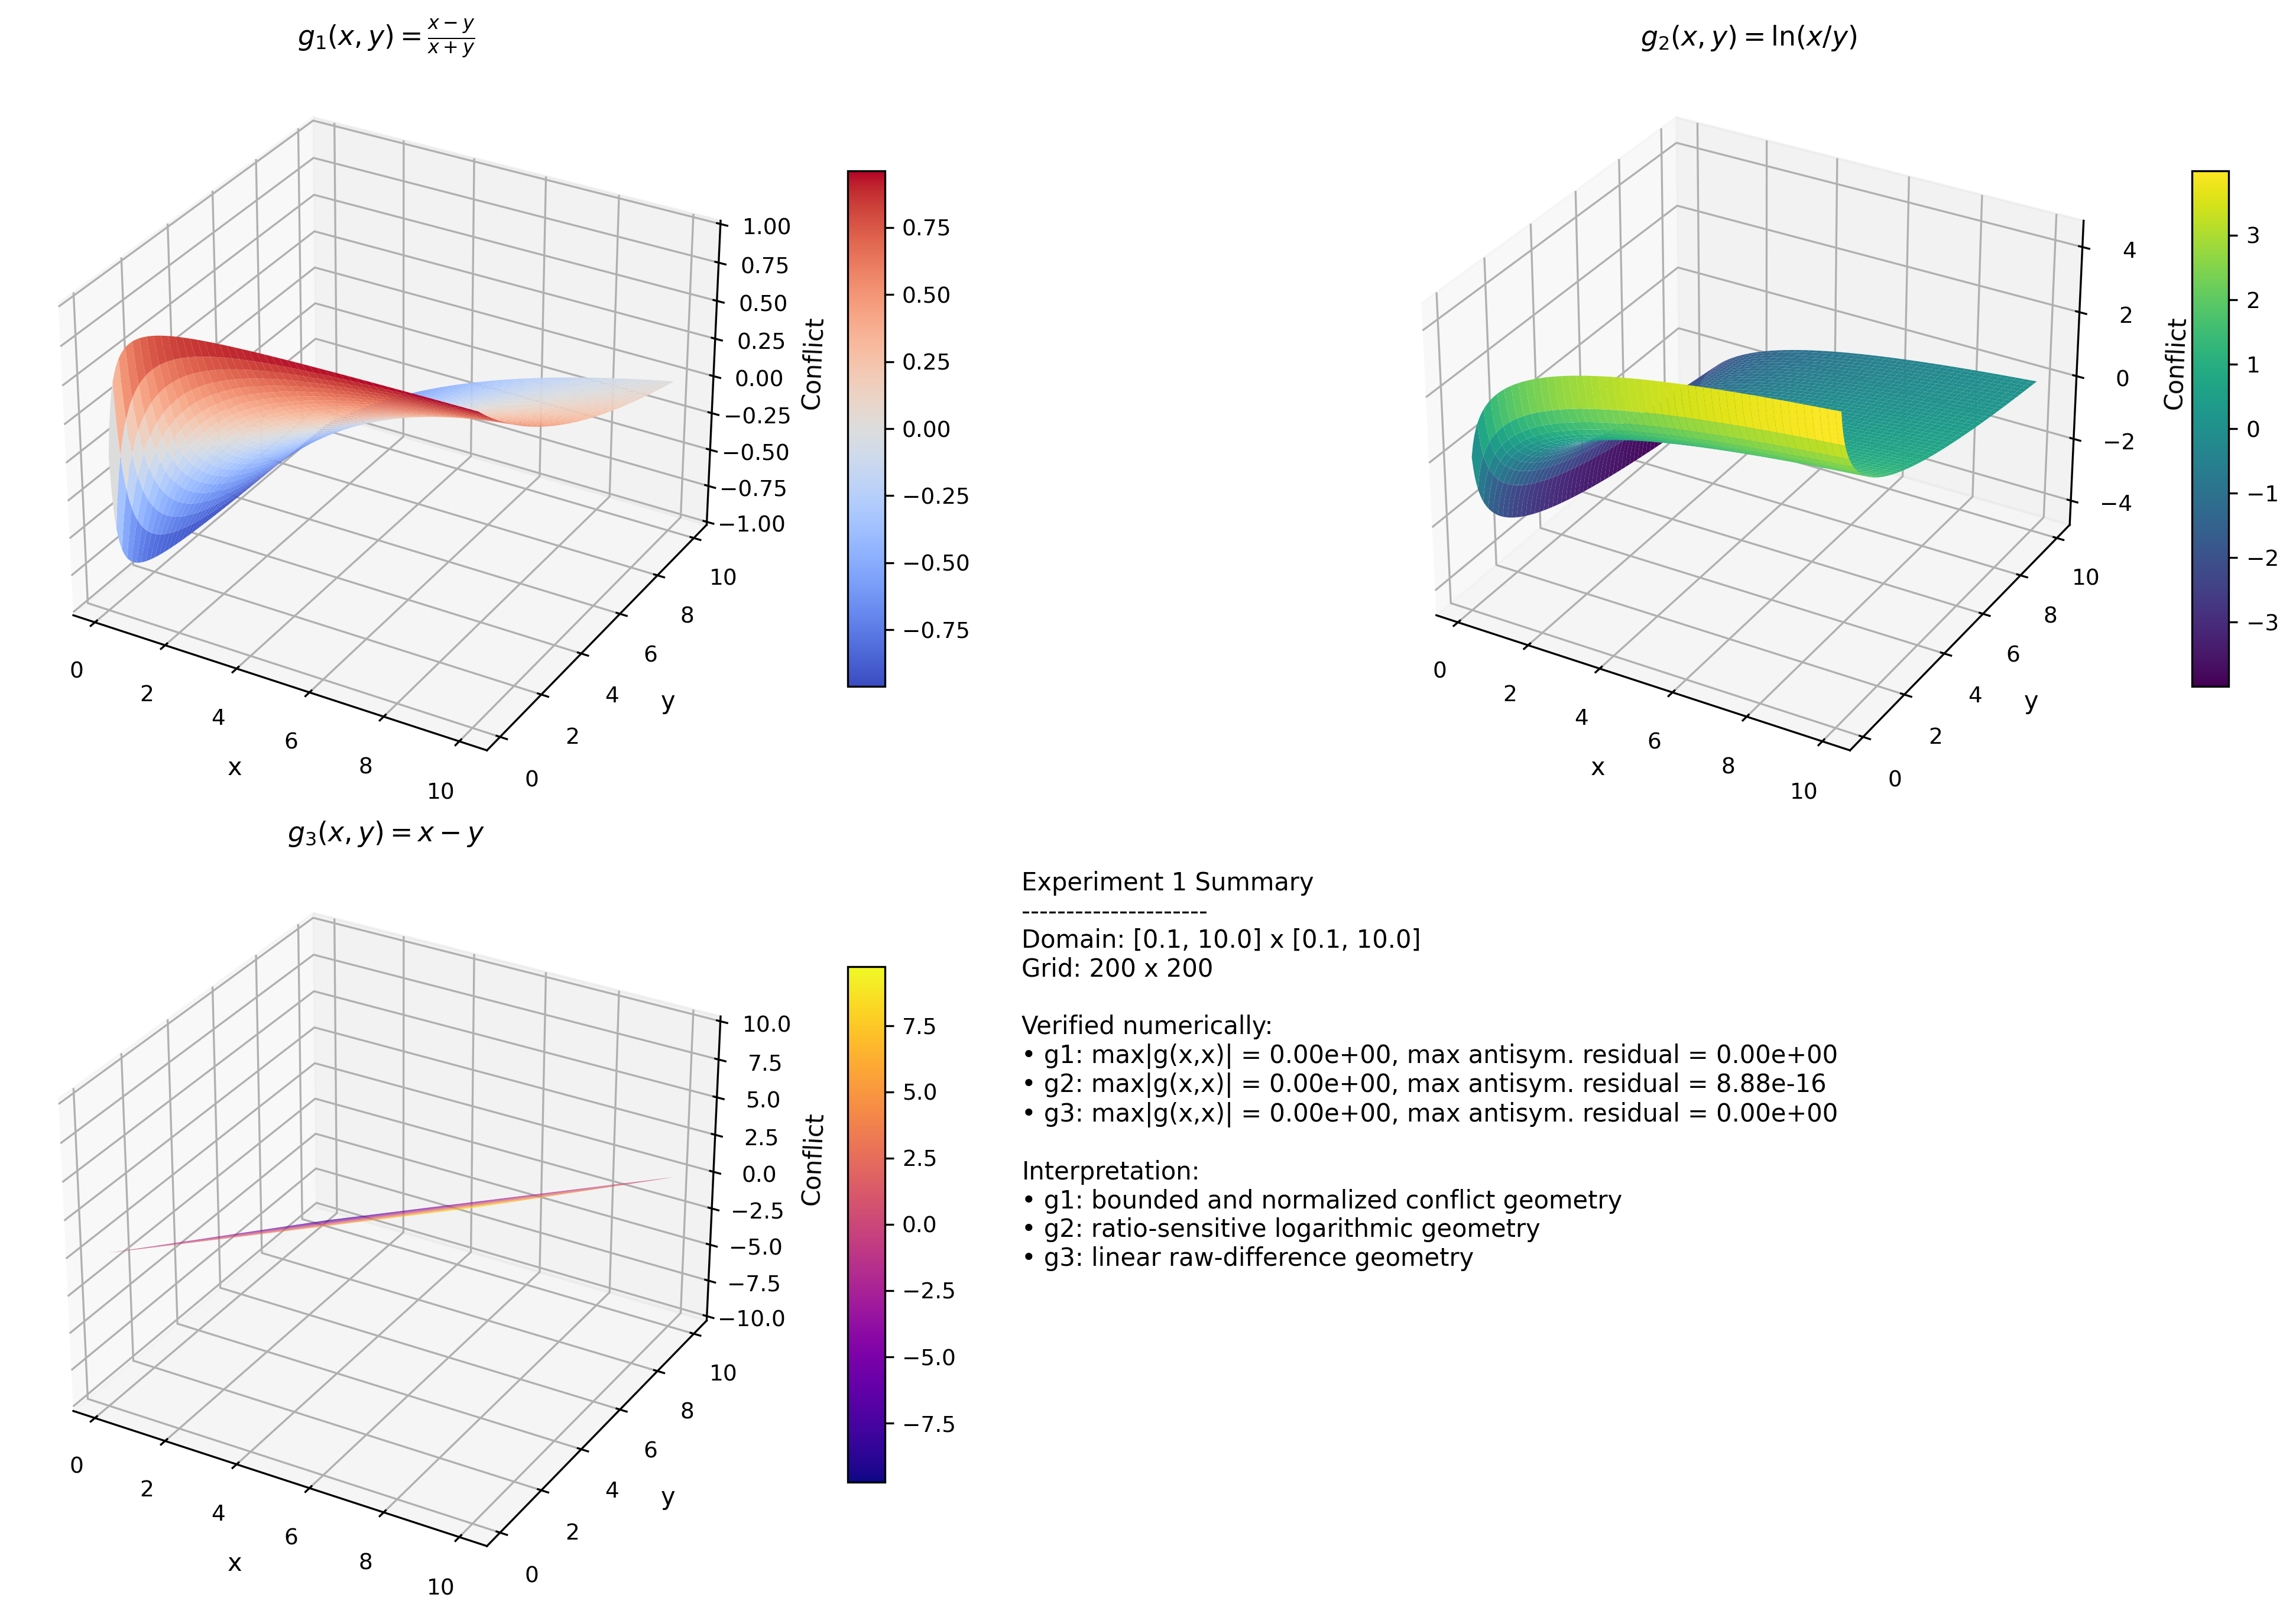

Saved: experiment1_3d_surfaces.png


In [ ]:
if make_3d_figure:
    fig3 = plt.figure(figsize=(15, 9), constrained_layout=True)

    ax1 = fig3.add_subplot(2, 2, 1, projection="3d")
    surf1 = ax1.plot_surface(X, Y, G1, cmap=cm.coolwarm, linewidth=0, antialiased=True)
    ax1.set_title(r"$g_1(x,y)=\frac{x-y}{x+y}$")
    ax1.set_xlabel("x")
    ax1.set_ylabel("y")
    ax1.set_zlabel("Conflict")
    fig3.colorbar(surf1, ax=ax1, shrink=0.70, aspect=14)

    ax2 = fig3.add_subplot(2, 2, 2, projection="3d")
    surf2 = ax2.plot_surface(X, Y, G2, cmap=cm.viridis, linewidth=0, antialiased=True)
    ax2.set_title(r"$g_2(x,y)=\ln(x/y)$")
    ax2.set_xlabel("x")
    ax2.set_ylabel("y")
    ax2.set_zlabel("Conflict")
    fig3.colorbar(surf2, ax=ax2, shrink=0.70, aspect=14)

    ax3 = fig3.add_subplot(2, 2, 3, projection="3d")
    surf3 = ax3.plot_surface(X, Y, G3, cmap=cm.plasma, linewidth=0, antialiased=True)
    ax3.set_title(r"$g_3(x,y)=x-y$")
    ax3.set_xlabel("x")
    ax3.set_ylabel("y")
    ax3.set_zlabel("Conflict")
    fig3.colorbar(surf3, ax=ax3, shrink=0.70, aspect=14)

    ax4 = fig3.add_subplot(2, 2, 4)
    ax4.axis("off")
    summary_text = (
        "Experiment 1 Summary\n"
        "---------------------\n"
        f"Domain: [{a}, {b}] x [{a}, {b}]\n"
        f"Grid: {n} x {n}\n\n"
        "Verified numerically:\n"
        f"• g1: max|g(x,x)| = {E1_diag:.2e}, max antisym. residual = {E1_anti:.2e}\n"
        f"• g2: max|g(x,x)| = {E2_diag:.2e}, max antisym. residual = {E2_anti:.2e}\n"
        f"• g3: max|g(x,x)| = {E3_diag:.2e}, max antisym. residual = {E3_anti:.2e}\n\n"
        "Interpretation:\n"
        "• g1: bounded and normalized conflict geometry\n"
        "• g2: ratio-sensitive logarithmic geometry\n"
        "• g3: linear raw-difference geometry"
    )
    ax4.text(0.02, 0.98, summary_text, va="top", ha="left", fontsize=10)

    exploratory_fig = "experiment1_3d_surfaces.png"
    plt.savefig(exploratory_fig, dpi=300, bbox_inches="tight")
    plt.show()

    print(f"Saved: {exploratory_fig}")
else:
    print("3D figure generation is disabled.")

## 9. Interpretation notes

Expected interpretation of the outputs:

- **g1** should appear bounded and normalized.
- **g2** should emphasize ratio differences and remain unbounded in principle.
- **g3** should preserve raw magnitude differences and therefore be scale-dependent.

If the diagonal residuals and antisymmetry residuals are at machine precision level, the numerical results are consistent with the axiomatic properties stated in the paper.